In [4]:
import pandas as pd

path = "/work/keisuke-o/ws/tprt/datasets/dataset_xu_2024/Protein/split_0/test_target.csv"
df = pd.read_csv(path, header=None)
df

,0
0,-0.283150
1,0.034310
2,-0.943258
3,-1.123331
4,1.038700
...,...
9141,-1.109920
9142,0.969189
9143,-0.975478
9144,-0.694000


In [13]:
import numpy as np

# rmse (predictions are 0 for all)
def rmse(predictions, targets):
    return np.sqrt(np.mean((predictions - targets) ** 2))

# Calculate RMSE
predictions = np.zeros_like(df.values)
targets = df.values
rmse_value = rmse(predictions, targets)
print(f"RMSE: {rmse_value:.4f}")

RMSE: 1.0033


In [14]:
100 // 4

25

In [15]:
36584 % 1024

744

In [16]:
6553 % 1024

409

Starting model training...
Epoch 0/30, ELBO: 10691968.76


Epoch 10/30, ELBO: 541740661.37
Epoch 20/30, ELBO: 8123327461.53
Training complete.


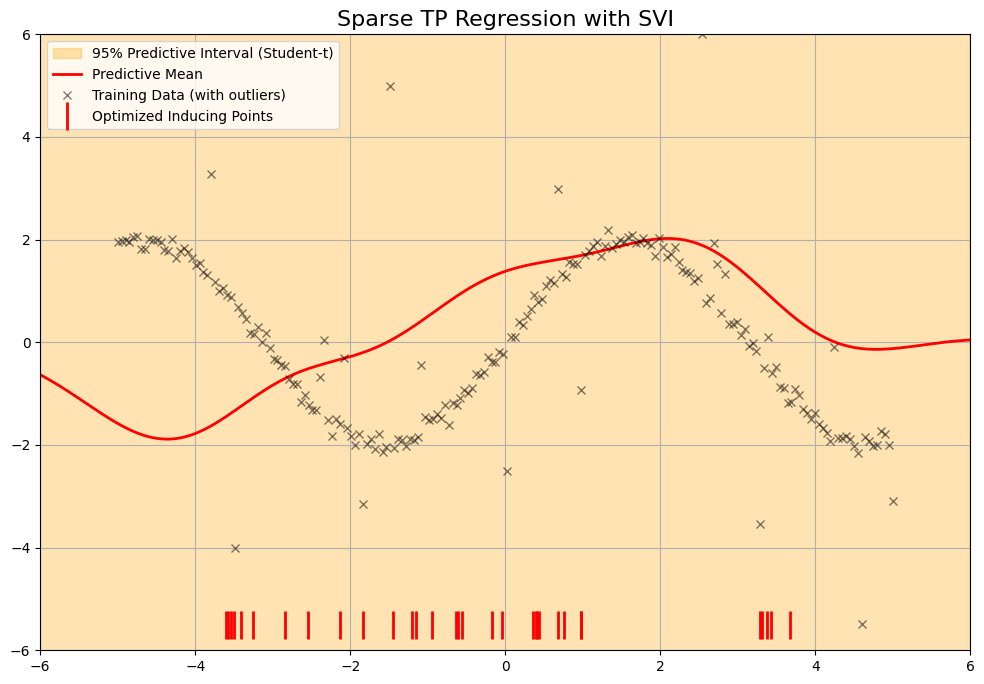

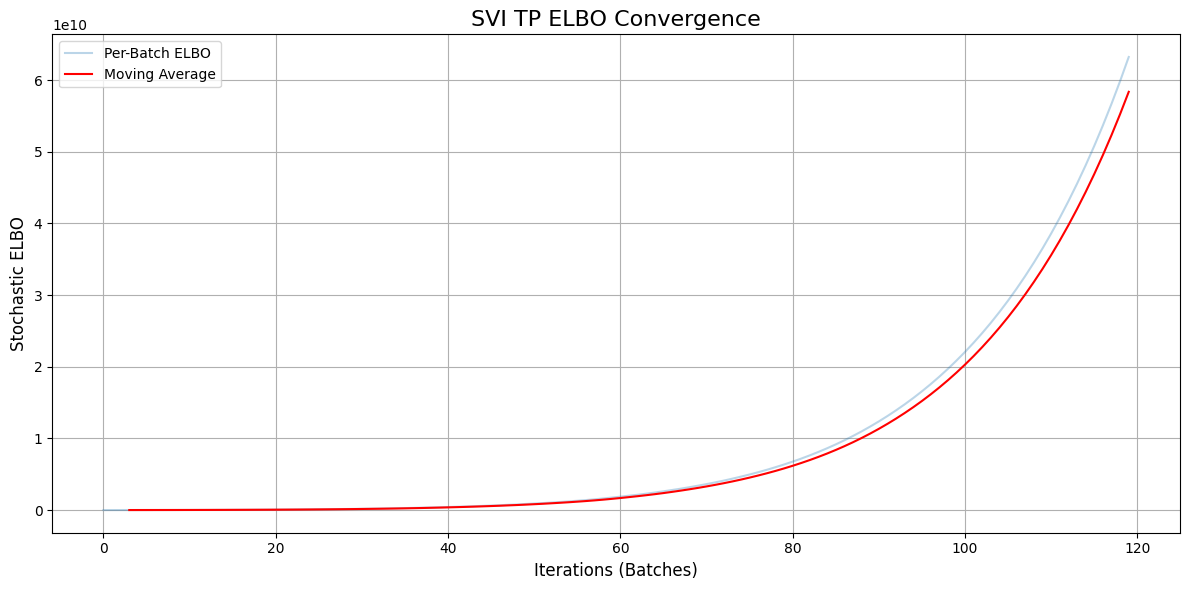

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from scipy.stats import t
import pandas as pd
import math

# Use a softplus transformation to ensure parameters that must be positive remain so.
softplus = nn.Softplus()

class SparseTPSVI(nn.Module):
    """
    Implements a Sparse Student-t Process regression model using Stochastic
    Variational Inference (SVI). All parameters (variational, hyperparameters,
    inducing locations, degrees of freedom) are optimized simultaneously.
    """
    def __init__(self, X, y, M, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()
        self.X = X
        self.y = y
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Model Hyperparameters ---
        # These are treated as learnable parameters.
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        
        # Degrees of freedom for the prior (f) and likelihood (e)
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Initialize Inducing Points ---
        # Start with a random subset of the training data.
        initial_indices = torch.randperm(self.N)[:self.M]
        self.Z = nn.Parameter(self.X[initial_indices].clone())

        # --- Initialize Variational Parameters ---
        # q(u) ~ N(q_mu, q_sqrt @ q_sqrt.T)
        self.q_mu = nn.Parameter(torch.zeros(self.M, 1))
        self.q_sqrt = nn.Parameter(torch.eye(self.M)) # Cholesky factor of the covariance

        # q(r) ~ Gamma(alpha_r, beta_r)
        # We learn unconstrained parameters and transform them to be positive.
        self._q_alpha_r = nn.Parameter(torch.randn(1))
        self._q_beta_r = nn.Parameter(torch.randn(1))

        # q(lambda_i) ~ Gamma(alpha_lambda_i, beta_lambda_i)
        self._q_alpha_lambda = nn.Parameter(torch.randn(self.N))
        self._q_beta_lambda = nn.Parameter(torch.randn(self.N))

    def _kernel(self, X1, X2):
        """
        Computes the Radial Basis Function (RBF) kernel matrix.
        """
        variance = softplus(self.log_kernel_variance)
        lengthscale = softplus(self.log_kernel_lengthscale)
        
        # Use broadcasting to compute squared distances efficiently
        X1_sq = X1.pow(2).sum(1, keepdim=True)
        X2_sq = X2.pow(2).sum(1, keepdim=True)
        dist_sq = X1_sq + X2_sq.T - 2 * (X1 @ X2.T)
        
        return variance * torch.exp(-0.5 * dist_sq / lengthscale.pow(2))

    def _elbo(self, x_batch, y_batch, batch_indices):
        """
        Computes the Evidence Lower Bound (ELBO) for a mini-batch.
        This serves as the loss function to be maximized.
        """
        # --- Get constrained (positive) parameters ---
        nu_f = softplus(self.log_nu_f)
        nu_e = softplus(self.log_nu_e)
        sigma2 = softplus(self.log_likelihood_sigma).pow(2)
        
        q_alpha_r = softplus(self._q_alpha_r)
        q_beta_r = softplus(self._q_beta_r)
        q_alpha_lambda = softplus(self._q_alpha_lambda[batch_indices])
        q_beta_lambda = softplus(self._q_beta_lambda[batch_indices])

        # --- Compute Kernel Matrices ---
        Kzz = self._kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Kzx = self._kernel(self.Z, x_batch)
        Kxx_diag = softplus(self.log_kernel_variance).expand(x_batch.shape[0])

        # Cholesky decomposition for stable inversion
        Lzz = torch.linalg.cholesky(Kzz)
        Lzz_inv = torch.linalg.inv(Lzz)
        Kzz_inv = Lzz_inv.T @ Lzz_inv

        # --- Term 1: Expected Log-Likelihood ---
        # E_q[log p(y|f, {lambda_i})]
        
        # E[lambda_i] and E[log lambda_i]
        E_lambda = q_alpha_lambda / q_beta_lambda
        E_log_lambda = torch.digamma(q_alpha_lambda) - torch.log(q_beta_lambda)
        
        # E[f] and Var[f] for the batch
        A = torch.linalg.solve_triangular(Lzz, Kzx, upper=False)
        E_f = A.T @ self.q_mu
        
        q_cov_u = self.q_sqrt @ self.q_sqrt.T
        Var_f_term1 = Kxx_diag - (A * A).sum(0)
        Var_f_term2 = (A.T @ q_cov_u @ A).diag()
        
        E_r_inv = q_beta_r / (q_alpha_r - 1) if q_alpha_r > 1 else q_beta_r / q_alpha_r # Fallback
        Var_f = E_r_inv * Var_f_term1 + Var_f_term2
        
        # E[(y - f)^2]
        E_sq_error = (y_batch - E_f).pow(2) + Var_f.view(-1, 1)

        # Combine for expected log-likelihood
        expected_log_likelihood = 0.5 * (E_log_lambda.sum() - torch.log(2 * torch.tensor(math.pi)) * len(x_batch) - (E_lambda.view(-1, 1) * E_sq_error / sigma2).sum())

        # --- Term 2: KL Divergence KL(q(u)q(r) || p(u,r)) ---
        # This can be decomposed and calculated analytically.
        E_r = q_alpha_r / q_beta_r
        E_log_r = torch.digamma(q_alpha_r) - torch.log(q_beta_r)
        
        # Log probability of q(u)
        log_q_u = -0.5 * (self.M * torch.log(2 * torch.tensor(math.pi)) + torch.linalg.slogdet(q_cov_u)[1])
        
        # Log probability of p(u|r)
        E_log_p_u_r = -0.5 * (self.M * torch.log(2 * torch.tensor(math.pi)) + torch.linalg.slogdet(Kzz)[1] - self.M * E_log_r + E_r * (self.q_mu.T @ Kzz_inv @ self.q_mu + torch.trace(Kzz_inv @ q_cov_u)))
        
        # KL for r: KL(q(r) || p(r))
        p_alpha_r, p_beta_r = nu_f / 2.0, nu_f / 2.0
        kl_r = (q_alpha_r - p_alpha_r) * torch.digamma(q_alpha_r) - torch.lgamma(q_alpha_r) + torch.lgamma(p_alpha_r) \
               - q_beta_r.log() + p_alpha_r * p_beta_r.log() + q_beta_r * (E_r - p_beta_r)

        kl_prior = E_log_p_u_r - log_q_u + kl_r

        # --- Term 3: KL Divergence KL(q(lambda) || p(lambda)) ---
        p_alpha_lambda, p_beta_lambda = nu_e / 2.0, nu_e / 2.0
        kl_lambda = (q_alpha_lambda - p_alpha_lambda) * torch.digamma(q_alpha_lambda) - torch.lgamma(q_alpha_lambda) + torch.lgamma(p_alpha_lambda) \
                   - q_beta_lambda.log() + p_alpha_lambda * p_beta_lambda.log() + q_beta_lambda * (E_lambda - p_beta_lambda)
        
        # Scale KL terms for mini-batching
        # The likelihood KL is local, so we sum over the batch.
        # The prior KL is global, so we scale it by the batch size relative to the total data size.
        kl_lambda_sum = kl_lambda.sum()
        scale = float(self.N) / float(len(x_batch))
        
        elbo = expected_log_likelihood - scale * kl_prior - kl_lambda_sum
        return elbo

    def fit(self, epochs=1000, batch_size=100, lr_variational=0.01, lr_hyper=0.01):
        """
        Trains the model using Adam optimizer.
        """
        dataset = TensorDataset(self.X, self.y, torch.arange(self.N))
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # Separate optimizers for variational parameters and hyperparameters
        # can sometimes lead to more stable training.
        variational_params = [self.q_mu, self.q_sqrt, self._q_alpha_r, self._q_beta_r, self._q_alpha_lambda, self._q_beta_lambda]
        hyper_params = [self.log_kernel_lengthscale, self.log_kernel_variance, self.log_likelihood_sigma, self.Z, self.log_nu_f, self.log_nu_e]
        
        opt_variational = torch.optim.Adam(variational_params, lr=lr_variational)
        opt_hyper = torch.optim.Adam(hyper_params, lr=lr_hyper)

        elbo_history = []
        for epoch in range(epochs):
            for i, (x_batch, y_batch, batch_indices) in enumerate(dataloader):
                opt_variational.zero_grad()
                opt_hyper.zero_grad()
                
                # We want to maximize ELBO, so we minimize its negative.
                loss = -self._elbo(x_batch, y_batch, batch_indices)
                
                loss.backward()
                
                opt_variational.step()
                opt_hyper.step()
                
                elbo_history.append(-loss.item())

            if epoch % 10 == 0:
                print(f"Epoch {epoch}/{epochs}, ELBO: {elbo_history[-1]:.2f}")
        
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data points X_test.
        """
        with torch.no_grad():
            # --- Predictive Mean ---
            Kzz = self._kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Kxt_z = self._kernel(X_test, self.Z)
            Lzz = torch.linalg.cholesky(Kzz)
            
            A = torch.linalg.solve_triangular(Lzz, Kxt_z.T, upper=False)
            pred_mean = A.T @ self.q_mu

            # --- Predictive Variance ---
            Ktt_diag = softplus(self.log_kernel_variance).expand(X_test.shape[0])
            q_cov_u = self.q_sqrt @ self.q_sqrt.T
            
            q_alpha_r = softplus(self._q_alpha_r)
            q_beta_r = softplus(self._q_beta_r)
            E_r_inv = q_beta_r / (q_alpha_r - 1) if q_alpha_r > 1 else q_beta_r / q_alpha_r

            var_term1 = E_r_inv * (Ktt_diag - (A * A).sum(0))
            var_term2 = (A.T @ q_cov_u @ A).diag()
            pred_var = var_term1 + var_term2

            # The predictive distribution is a Student-t.
            # The degrees of freedom are derived from the posterior of r.
            pred_nu = 2 * q_alpha_r

            return pred_mean.squeeze(), pred_var.squeeze(), pred_nu


if __name__ == '__main__':
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. Generate 1D data with outliers ---
    N = 200
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    # Add some Gaussian noise
    noise = torch.randn(N, 1) * 0.1
    
    # Add heavy-tailed noise for outliers
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Select random indices to place outliers
    outlier_indices = torch.randperm(N)[:20]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    # Add some specific, large outliers
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. Set up the model ---
    M = 32 # Number of inducing points
    model = SparseTPSVI(
        X=X_train, y=y_train, M=M,
        nu_f=5.0, nu_e=5.0,
        kernel_lengthscale=0.5, kernel_variance=2.0, likelihood_sigma=0.5
    )

    # --- 3. Train the model ---
    print("Starting model training...")
    elbo_history = model.fit(epochs=30, batch_size=50, lr_variational=0.01, lr_hyper=0.01)
    print("Training complete.")

    # --- 4. Make predictions ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. Visualize regression results ---
    plt.figure(figsize=(12, 8))
    
    # Calculate the 95% predictive interval using the Student-t distribution
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    # Use the percent point function (inverse of CDF) to get the quantiles
    lower_quantile = t.ppf(0.025, df=df, scale=pred_scale.cpu().numpy())
    upper_quantile = t.ppf(0.975, df=df, scale=pred_scale.cpu().numpy())
    lower = pred_mean.cpu() + lower_quantile
    upper = pred_mean.cpu() + upper_quantile

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean.cpu(), 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach().cpu(), torch.full_like(model.Z.detach().cpu(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    
    plt.title('Sparse TP Regression with SVI', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. Visualize ELBO history ---
    plt.figure(figsize=(12, 6))
    elbo_series = pd.Series(elbo_history)
    # Calculate a moving average to see the trend more clearly
    num_batches = math.ceil(len(X_train) / 50)
    elbo_moving_avg = elbo_series.rolling(window=num_batches).mean()
    
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('SVI TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()



In [19]:
import torch


def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    """
    Computes the RBF kernel matrix with ARD support.

    Args:
        X1 (torch.Tensor): A tensor of size (N, D).
        X2 (torch.Tensor): A tensor of size (M, D).
        lengthscale (torch.Tensor): A tensor of size (D,) representing the lengthscale for each dimension.
        variance (float): The kernel variance.
    """
    # Ensure variance is a tensor on the correct device
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    # Scale each dimension of X1 and X2 by the corresponding lengthscale
    # This uses broadcasting to efficiently perform the operation
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    
    # Compute the squared Euclidean distance in the scaled space
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    
    return variance * torch.exp(-0.5 * sqdist)


def matern52_kernel(X1, X2, lengthscale, variance=1.0):
    sqdist = torch.cdist(X1 / lengthscale, X2 / lengthscale, p=2)
    term1 = 1 + torch.sqrt(5) * sqdist + (5/3) * sqdist**2
    term2 = torch.exp(-torch.sqrt(5) * sqdist)
    return variance * term1 * term2


import torch

# --- Helper class for Priors ---
class GammaPrior:
    def __init__(self, concentration, rate):
        self.concentration = concentration
        self.rate = rate

    def log_prob(self, x):
        # Log probability density of Gamma distribution (constants omitted)
        return (self.concentration - 1.0) * torch.log(x.clamp(min=1e-9)) - self.rate * x

class LogNormalPrior:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale
        self.var = scale**2

    def log_prob(self, x):
        # Log probability density of LogNormal distribution (constants omitted)
        log_x = torch.log(x.clamp(min=1e-9))
        return -log_x - (log_x - self.loc)**2 / (2 * self.var)

Starting Variational EM optimization...


ELBO: 211.1740: 100%|██████████| 100/100 [00:15<00:00,  6.49it/s]



Optimization finished.


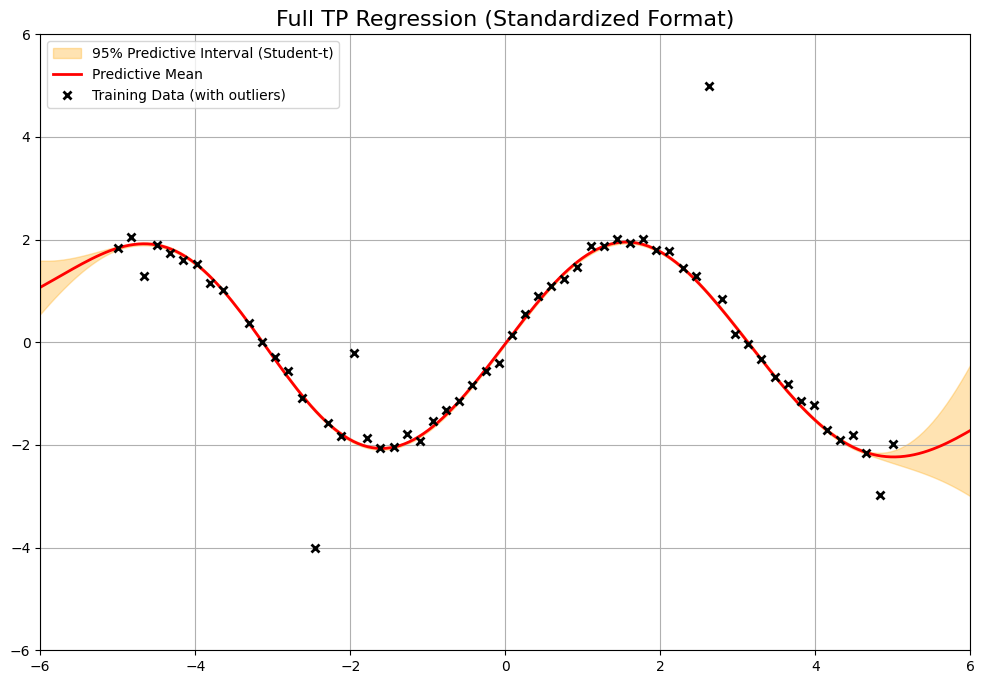

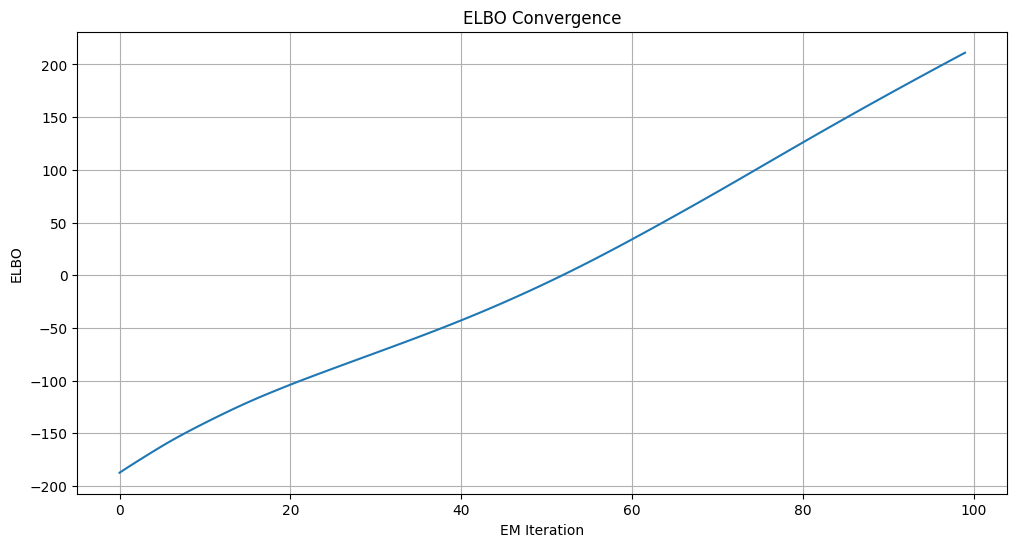

In [24]:
# from .kernels import rbf_kernel
# from .priors import GammaPrior, LogNormalPrior
import torch
import torch.nn as nn
import math
import logging
import tqdm


torch.set_default_dtype(torch.float64)

class TPRTFullBatch(nn.Module):
    # +++ 2. __init__ を修正 +++
    def __init__(self, X, y, kernel=rbf_kernel, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        super().__init__()
        
        self.X = X
        self.y = y.view(-1, 1)
        self.N, self.D = X.shape

        dtype = self.X.dtype
        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        
        if kernel_lengthscale.shape[0] != self.D:
            raise ValueError(f"lengthscale must be a scalar or a vector of length D={self.D}")

        # カーネル関数をインスタンス変数として保持
        self.kernel = kernel

        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))

        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)
        self.L_f = torch.eye(self.N, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.alpha_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)
        self.beta_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma_sq": torch.exp(self.log_likelihood_sigma_sq),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }

    def _update_q_lambda(self, params):
        S_f = self.L_f @ self.L_f.T
        var_f = S_f.diag().unsqueeze(1)
        expected_f_mean = self.m_f
        self.alpha_lambda = params['nu_e'] / 2.0 + 0.5
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        self.beta_lambda = params['nu_e'] / 2.0 + (1.0 / (2.0 * params['sigma_sq'])) * expected_sq_error

    def _update_q_r(self, params, Lxx):
        S_f = self.L_f @ self.L_f.T
        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        mean_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        expected_f_quadratic_form = trace_term + mean_term
        self.alpha_r = params['nu_f'] / 2.0 + self.N / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_f_quadratic_form.squeeze()

    def _update_q_f(self, params, Lxx):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = expected_r * Kxx_inv + torch.diag(expected_lambda.squeeze() / params['sigma_sq'])
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N, device=self.X.device), L_f_inv, upper=False)[0]
        temp_vec = (expected_lambda / params['sigma_sq']) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, params, Lxx):
        self._update_q_lambda(params)
        self._update_q_r(params, Lxx)
        self._update_q_f(params, Lxx)
        
    def _e_step(self, cavi_max_iter=10, cavi_tol=1e-5):
        with torch.no_grad():
            params = self._get_hyperparams()
            # +++ 3. self.kernel を呼び出し +++
            Kxx = self.kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)
            for _ in range(cavi_max_iter):
                m_f_prev = self.m_f.clone()
                self._cavi_step(params, Lxx)
                m_f_rel_change = torch.norm(self.m_f - m_f_prev) / (torch.norm(m_f_prev) + 1e-8)
                if m_f_rel_change < cavi_tol:
                    break
    
    def _calculate_neg_log_prior_prob(self):
        params = self._get_hyperparams()
        log_prior_lengthscale = self.lengthscale_prior.log_prob(params['lengthscale'])
        log_prior_variance = self.variance_prior.log_prob(params['variance'])
        log_prior_sigma = self.sigma_sq_prior.log_prob(params['sigma_sq'])
        log_prior_nu_f = self.nu_prior.log_prob(params['nu_f'])
        log_prior_nu_e = self.nu_prior.log_prob(params['nu_e'])
        neg_log_prior = -(log_prior_lengthscale.sum() + log_prior_variance + 
                          log_prior_sigma + log_prior_nu_f + log_prior_nu_e)
        return neg_log_prior

    def _m_step(self, optimizer):
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        neg_log_prior = self._calculate_neg_log_prior_prob()
        loss = -elbo + neg_log_prior
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, cavi_tol=1e-5, lr=0.01):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        elbo_history = []
        print("Starting Variational EM optimization...")
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            self._e_step(cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            pbar.set_description(f"ELBO: {elbo:.4f}")
        print("\nOptimization finished.")
        return elbo_history

    def _calculate_elbo(self):
        params = self._get_hyperparams()
        # +++ 3. self.kernel を呼び出し +++
        Kxx = self.kernel(self.X, self.X, params['lengthscale'], params['variance'])
        Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
        Lxx = torch.linalg.cholesky(Kxx)
        S_f = self.L_f @ self.L_f.T
        E_q_f = self.m_f
        Var_q_f = S_f.diag().unsqueeze(1)
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        e_log_lik = -0.5 * self.N * math.log(2 * math.pi) - 0.5 * self.N * torch.log(params['sigma_sq']) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / params['sigma_sq'] * torch.sum(E_lambda * expected_sq_error)
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        log_q_f = -torch.sum(torch.log(torch.diag(self.L_f)))
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r
        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        quad_form_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        E_quad_form_f = trace_term + quad_form_term
        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * log_det_Kxx + 0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        E_log_p_r = p_alpha_r * torch.log(p_beta_r) - torch.lgamma(p_alpha_r) + \
                    (p_alpha_r - 1) * E_log_r - p_beta_r * E_r
        kl_f_r_grouped = (log_q_f + log_q_r) - (E_log_p_f_r + E_log_p_r)
        p_alpha_lambda, p_beta_lambda = params['nu_e'] / 2.0, params['nu_e'] / 2.0
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(p_alpha_lambda) - p_alpha_lambda * torch.log(p_beta_lambda)) - \
                    (self.alpha_lambda - p_alpha_lambda) * E_log_lambda + \
                    (self.beta_lambda - p_beta_lambda) * E_lambda
        kl_lambda_sum = torch.sum(kl_lambda)
        elbo = e_log_lik - kl_f_r_grouped - kl_lambda_sum
        return elbo

    def predict(self, X_test):
        with torch.no_grad():
            params = self._get_hyperparams()
            # +++ 3. self.kernel を呼び出し +++
            K_star_x = self.kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = self.kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()
            Kxx = self.kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))
            pred_var = var_from_prior + var_from_q_f
            pred_var = pred_var.clamp(min=1e-9)
            pred_nu = 2 * self.alpha_r
            return pred_mean, pred_var.unsqueeze(1), pred_nu
        
    def evaluate_model(self, max_iter_global=100, cavi_max_iter=10, cavi_tol=1e-5, lr=0.01,
                       X_test=None, y_test=None, eval_interval=100,
                       result_path=None):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        can_evaluate = X_test is not None and y_test is not None and result_path is not None
        if can_evaluate and not result_path.exists():
            result_path.parent.mkdir(parents=True, exist_ok=True)
            with open(result_path, 'w') as f:
                f.write("iteration,rmse,elbo\n")

        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
            elbo = self._m_step(optimizer)

            if can_evaluate and (i + 1) % eval_interval == 0:
                with torch.no_grad():
                    pred_mean, _, _ = self.predict(X_test)
                    rmse = torch.sqrt(torch.mean((y_test.view(-1) - pred_mean.view(-1))**2)).item()
                logging.info(f"EM Iteration {i+1}/{max_iter_global}, Test RMSE: {rmse:.4f}")
                with open(result_path, 'a') as f:
                    f.write(f"{i+1},{rmse},{elbo}\n")
        
        if can_evaluate and max_iter_global % eval_interval != 0:
             with torch.no_grad():
                pred_mean, _, _ = self.predict(X_test)
                rmse = torch.sqrt(torch.mean((y_test.view(-1) - pred_mean.view(-1))**2)).item()
             with open(result_path, 'a') as f:
                f.write(f"{max_iter_global},{rmse},{elbo}\n")





if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    torch.set_default_dtype(torch.float64)

    # 1. Generate data
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.3
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = TPRTFullBatch(
        X=X_train,
        y=y_train,
        nu_f=3.0,
        nu_e=3.0,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=1.0
    )

    # 3. Fit the model
    elbo_history = model.fit(max_iter_global=100, cavi_max_iter=15, lr=0.05)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Full TP Regression (Standardized Format)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.figure(figsize=(12, 6))
    plt.plot(elbo_history)
    plt.title("ELBO Convergence")
    plt.xlabel("EM Iteration")
    plt.ylabel("ELBO")
    plt.grid(True)
    
    plt.show()

Starting SVIGP optimization for 150 epochs...
Epoch 10/150, Final Batch ELBO: -4315.2201
Epoch 20/150, Final Batch ELBO: -1685.0364
Epoch 30/150, Final Batch ELBO: -1241.9389
Epoch 40/150, Final Batch ELBO: -701.3759
Epoch 50/150, Final Batch ELBO: -609.3997
Epoch 60/150, Final Batch ELBO: -753.3128
Epoch 70/150, Final Batch ELBO: -569.6107
Epoch 80/150, Final Batch ELBO: -430.3089
Epoch 90/150, Final Batch ELBO: -468.1370
Epoch 100/150, Final Batch ELBO: -578.0760
Epoch 110/150, Final Batch ELBO: -655.5002
Epoch 120/150, Final Batch ELBO: -356.9315
Epoch 130/150, Final Batch ELBO: -364.5756
Epoch 140/150, Final Batch ELBO: -389.9025
Epoch 150/150, Final Batch ELBO: -381.4678

Optimization finished.


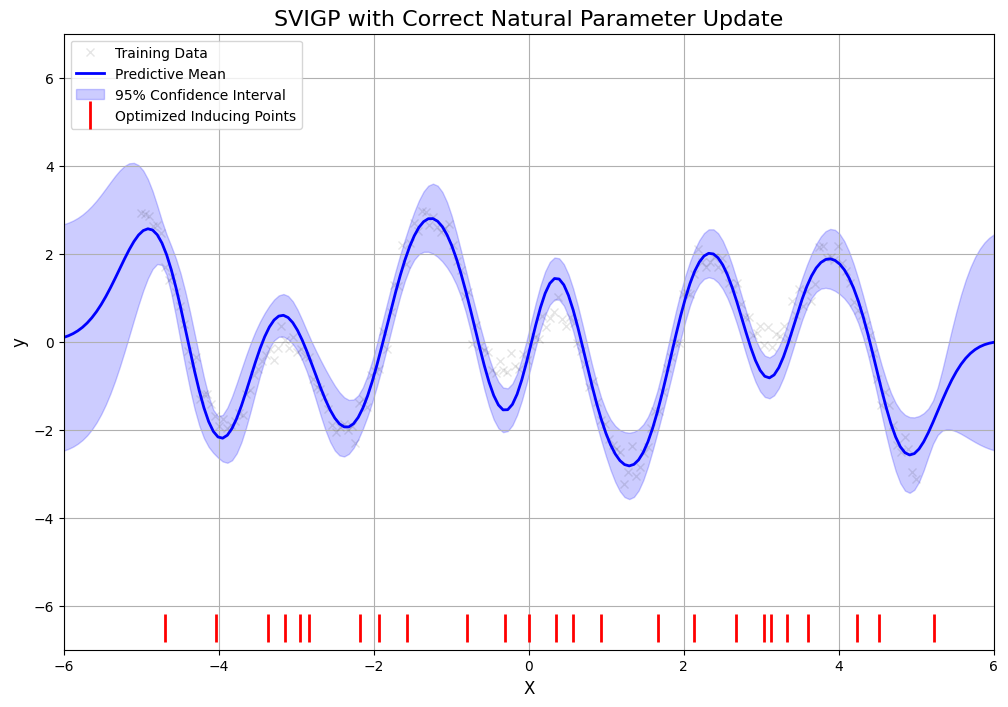

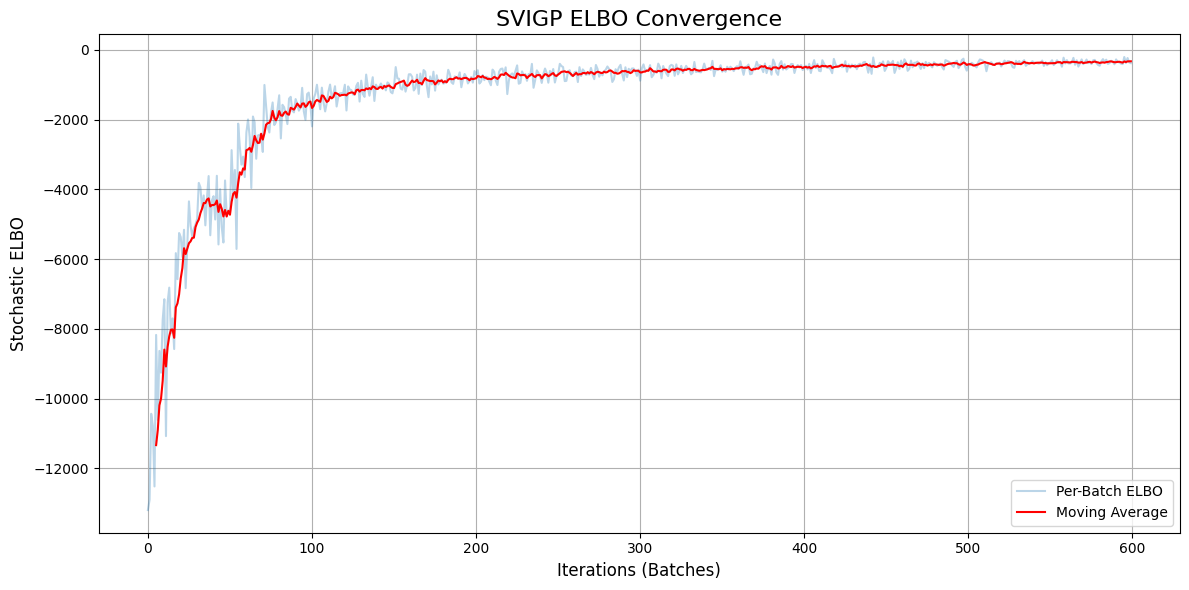

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Keep the provided kernel function
def rbf_kernel(X1, X2, lengthscale, variance):
    """
    Computes the RBF kernel matrix.
    """
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)


class SVIGP(nn.Module):
    """
    Implementation of the Stochastic Variational Inference Gaussian Process (SVIGP)
    with the CORRECT update rule for variational parameters performed in the
    natural parameter space.
    """
    def __init__(self, X, y, M, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_noise=0.1, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        self.Z = nn.Parameter(self._initialize_inducing_points())
        if not hasattr(kernel_lengthscale, "__len__"):
            kernel_lengthscale = torch.tensor([kernel_lengthscale] * self.D, dtype=dtype)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))
        self.log_beta = nn.Parameter(torch.log(torch.tensor(1.0 / likelihood_noise**2, dtype=dtype)))

        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('L_u', torch.eye(self.M, dtype=dtype))

        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "beta": torch.exp(self.log_beta)
        }

    def _calculate_elbo(self, X_batch, y_batch):
        B = X_batch.shape[0]
        params = self._get_params()
        S_u = self.L_u @ self.L_u.T

        K_ZZ = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
        K_ZZ += torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ = self.kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_XX_diag = params['variance'].expand(B)

        L_ZZ_inv_K_ZX = torch.cholesky_solve(K_XZ.T, L_ZZ)
        pred_mean_f = K_XZ @ torch.cholesky_solve(self.m_u, L_ZZ)
        K_tilde_diag = K_XX_diag - (K_XZ * L_ZZ_inv_K_ZX.T).sum(dim=1)
        var_f = K_tilde_diag + (L_ZZ_inv_K_ZX.T @ S_u @ L_ZZ_inv_K_ZX).diag()
        sum_sq_err_var = ((y_batch - pred_mean_f)**2 + var_f.unsqueeze(1)).sum()
        log_lik = 0.5 * self.N * (torch.log(params['beta']) - math.log(2 * math.pi)) - 0.5 * params['beta'] * (self.N / B) * sum_sq_err_var

        log_det_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        log_det_S_u = 2 * torch.sum(torch.log(torch.diag(self.L_u)))
        trace_term = torch.trace(torch.cholesky_solve(S_u, L_ZZ))
        mean_term = (self.m_u.T @ torch.cholesky_solve(self.m_u, L_ZZ)).squeeze()
        kl_div = 0.5 * (trace_term + mean_term - self.M + log_det_K_ZZ - log_det_S_u)
        
        return log_lik - kl_div

    def fit(self, epochs=100, batch_size=128, lr=0.01, rho=0.01):
        optimizer = optim.Adam(self.parameters(), lr=lr)
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting SVIGP optimization for {epochs} epochs...")
        
        jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
        
        for epoch in range(epochs):
            for X_batch, y_batch in dataloader:
                B = X_batch.shape[0]
                params = self._get_params()
                
                with torch.no_grad():
                    S_u_old_inv = torch.cholesky_inverse(self.L_u)
                    theta1_old = S_u_old_inv @ self.m_u
                    theta2_old = -0.5 * S_u_old_inv
                    
                    K_ZZ = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + jitter
                    K_XZ = self.kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
                    L_ZZ = torch.linalg.cholesky(K_ZZ)
                    K_ZZ_inv = torch.cholesky_inverse(L_ZZ)
                    
                    K_zx_K_xz = K_XZ.T @ K_XZ
                    K_zx_y = K_XZ.T @ y_batch
                    
                    S_batch_inv = K_ZZ_inv + (self.N / B) * params['beta'] * K_zx_K_xz
                    
                    theta1_batch = (self.N / B) * params['beta'] * K_zx_y
                    theta2_batch = -0.5 * S_batch_inv
                    
                    theta1_new = (1 - rho) * theta1_old + rho * theta1_batch
                    theta2_new = (1 - rho) * theta2_old + rho * theta2_batch
                    
                    S_u_new_inv = -2 * theta2_new
                    S_u_new = torch.inverse(S_u_new_inv)
                    m_u_new = S_u_new @ theta1_new
                    
                    self.m_u.data = m_u_new
                    self.L_u.data = torch.linalg.cholesky(S_u_new + jitter)

                optimizer.zero_grad()
                elbo = self._calculate_elbo(X_batch, y_batch)
                loss = -elbo
                loss.backward()
                optimizer.step()
                elbo_history.append(elbo.item())

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo.item():.4f}")
                
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        with torch.no_grad():
            params = self._get_params()
            jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
            
            K_ZZ = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + jitter
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_sZ = self.kernel(X_test_dev, self.Z, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'].expand(X_test_dev.shape[0])

            pred_mean = K_sZ @ torch.cholesky_solve(self.m_u, L_ZZ)

            L_ZZ_inv_K_Zs = torch.cholesky_solve(K_sZ.T, L_ZZ)
            S_u = self.L_u @ self.L_u.T
            
            var_f = K_ss_diag - (K_sZ * L_ZZ_inv_K_Zs.T).sum(dim=1) + \
                    (L_ZZ_inv_K_Zs.T @ S_u @ L_ZZ_inv_K_Zs).diag()
            
            pred_var = var_f + 1.0 / params['beta']
            
            return pred_mean.cpu(), pred_var.cpu()


if __name__ == '__main__':
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    N = 200
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * torch.cos(X_train * 2.5) * 3
    y_train = y_true + torch.randn(N, 1) * 0.2
    
    M = 25
    model = SVIGP(X_train, y_train, M=M)

    elbo_history = model.fit(
        epochs=150,
        batch_size=50,
        lr=0.01,
        rho=0.01
    )

    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)
    pred_std = torch.sqrt(pred_var.clamp(min=1e-9))

    # --- 5. Visualize the results (CORRECTED SECTION) ---
    plt.figure(figsize=(12, 8))
    
    # Squeeze predictive mean to ensure it's a 1D array for plotting
    pred_mean_1d = pred_mean.squeeze()
    
    # Calculate the confidence bounds using the 1D mean and 1D standard deviation
    lower_bound = pred_mean_1d - 1.96 * pred_std
    upper_bound = pred_mean_1d + 1.96 * pred_std
    
    plt.plot(X_train.numpy(), y_train.numpy(), 'kx', mew=1, alpha=0.1, label='Training Data')
    # Plot the 1D predictive mean
    plt.plot(X_test.squeeze().numpy(), pred_mean_1d.numpy(), 'b-', lw=2, label='Predictive Mean')
    
    # Use the 1D bounds for fill_between
    plt.fill_between(X_test.squeeze().numpy(), 
                     lower_bound.numpy(),
                     upper_bound.numpy(), 
                     color='blue', alpha=0.2, label='95% Confidence Interval')

    Z_final = model.Z.detach().cpu().numpy()
    plt.plot(Z_final, torch.full_like(torch.from_numpy(Z_final), -6.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('SVIGP with Correct Natural Parameter Update', fontsize=16)
    plt.xlabel('X', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-7, 7)
    
    # --- 6. Visualize ELBO convergence ---
    plt.figure(figsize=(12, 6))
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 100).mean()
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('SVIGP ELBO Convergence', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Starting SVIGP optimization for 300 epochs...


Epoch 10/300, Final Batch ELBO: -632.3492
Epoch 20/300, Final Batch ELBO: -445.5170
Epoch 30/300, Final Batch ELBO: -439.7595
Epoch 40/300, Final Batch ELBO: -402.6941
Epoch 50/300, Final Batch ELBO: -383.0371
Epoch 60/300, Final Batch ELBO: -366.2867
Epoch 70/300, Final Batch ELBO: -377.9947
Epoch 80/300, Final Batch ELBO: -352.3364
Epoch 90/300, Final Batch ELBO: -341.7953
Epoch 100/300, Final Batch ELBO: -335.7698
Epoch 110/300, Final Batch ELBO: -325.9929
Epoch 120/300, Final Batch ELBO: -316.0902
Epoch 130/300, Final Batch ELBO: -302.0669
Epoch 140/300, Final Batch ELBO: -291.1067
Epoch 150/300, Final Batch ELBO: -280.9500
Epoch 160/300, Final Batch ELBO: -279.4138
Epoch 170/300, Final Batch ELBO: -265.8100
Epoch 180/300, Final Batch ELBO: -252.8954
Epoch 190/300, Final Batch ELBO: -228.0122
Epoch 200/300, Final Batch ELBO: -217.1895
Epoch 210/300, Final Batch ELBO: -214.4592
Epoch 220/300, Final Batch ELBO: -215.5021
Epoch 230/300, Final Batch ELBO: -199.2978
Epoch 240/300, Final

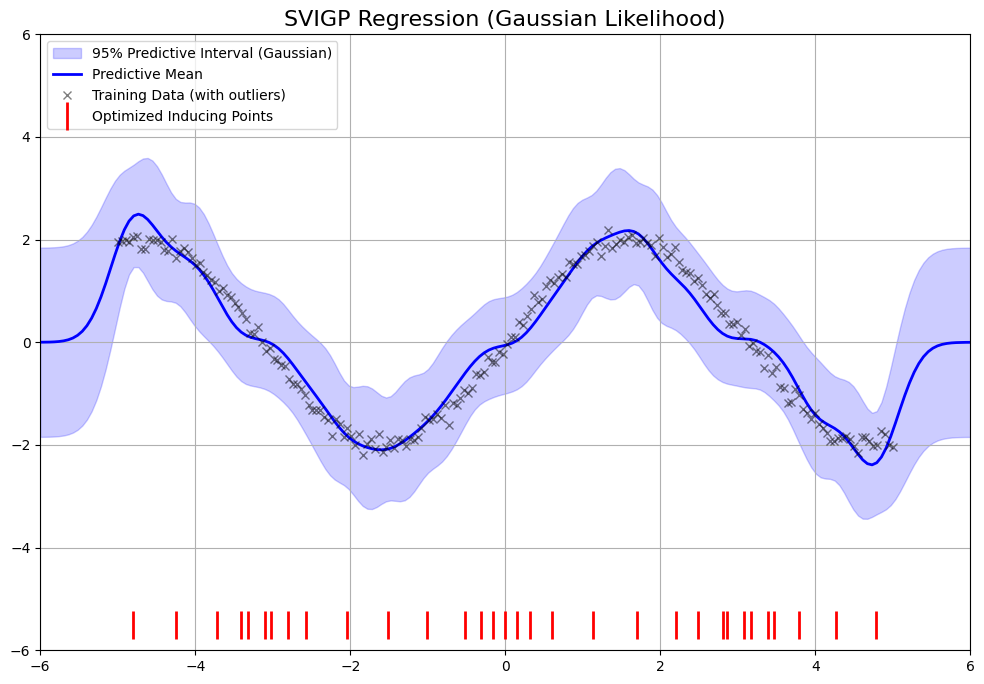

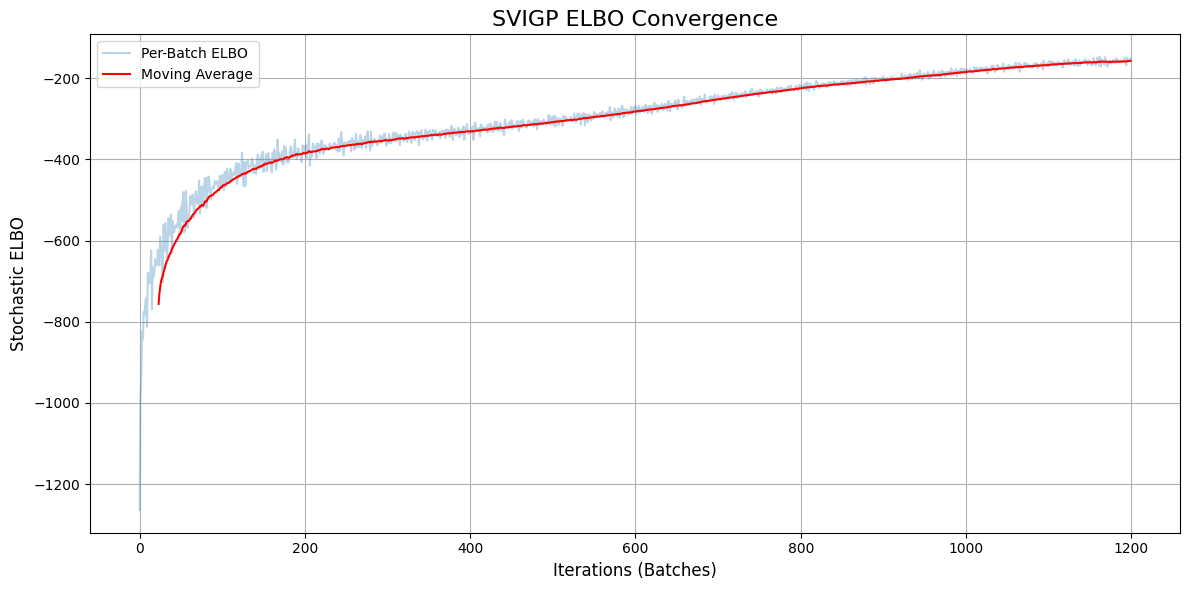

In [7]:

if __name__ == '__main__':
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    # outlier_indices = torch.randperm(N)[:20]
    # y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    # y_train[30] = -4.0
    # y_train[70] = 5.0
    # y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 32 # Number of inducing points
    
    # Instantiate the SVIGP model
    model = SVIGP(
        X=X_train,
        y=y_train,
        M=M,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_noise=0.5  # Start with higher noise to handle outliers
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(
        epochs=300,
        batch_size=50,
        lr=0.01,
        rho=0.01
    )

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    
    # **MODIFICATION**: Use 1.96 for Gaussian 95% interval
    pred_std = torch.sqrt(pred_var.clamp(min=1e-9))
    pred_mean_1d = pred_mean.squeeze()
    lower = pred_mean_1d - 1.96 * pred_std
    upper = pred_mean_1d + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower, upper, color='blue', alpha=0.2, label='95% Predictive Interval (Gaussian)')
    plt.plot(X_test, pred_mean, 'b-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach().cpu(), torch.full_like(model.Z.detach().cpu(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('SVIGP Regression (Gaussian Likelihood)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean()
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('SVIGP ELBO Convergence', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Keep the provided kernel function
def rbf_kernel(X1, X2, lengthscale, variance):
    """
    Computes the RBF kernel matrix.
    """
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)


class SVIGP(nn.Module):
    """
    Implementation of the Stochastic Variational Inference Gaussian Process (SVIGP)
    This version includes a scheduled learning rate for the variational parameter
    updates, mirroring the logic from the SparseTPRTMiniBatch model.
    """
    def __init__(self, X, y, M, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_noise=0.1, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        self.Z = nn.Parameter(self._initialize_inducing_points())
        if not hasattr(kernel_lengthscale, "__len__"):
            kernel_lengthscale = torch.tensor([kernel_lengthscale] * self.D, dtype=dtype)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))
        self.log_beta = nn.Parameter(torch.log(torch.tensor(1.0 / likelihood_noise**2, dtype=dtype)))

        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('L_u', torch.eye(self.M, dtype=dtype))

        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "beta": torch.exp(self.log_beta)
        }

    def _calculate_elbo(self, X_batch, y_batch):
        B = X_batch.shape[0]
        params = self._get_params()
        S_u = self.L_u @ self.L_u.T

        K_ZZ = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
        K_ZZ += torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ = self.kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_XX_diag = params['variance'].expand(B)

        L_ZZ_inv_K_ZX = torch.cholesky_solve(K_XZ.T, L_ZZ)
        pred_mean_f = K_XZ @ torch.cholesky_solve(self.m_u, L_ZZ)
        K_tilde_diag = K_XX_diag - (K_XZ * L_ZZ_inv_K_ZX.T).sum(dim=1)
        var_f = K_tilde_diag + (L_ZZ_inv_K_ZX.T @ S_u @ L_ZZ_inv_K_ZX).diag()
        sum_sq_err_var = ((y_batch - pred_mean_f)**2 + var_f.unsqueeze(1)).sum()
        log_lik = 0.5 * self.N * (torch.log(params['beta']) - math.log(2 * math.pi)) - 0.5 * params['beta'] * (self.N / B) * sum_sq_err_var

        log_det_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        log_det_S_u = 2 * torch.sum(torch.log(torch.diag(self.L_u)))
        trace_term = torch.trace(torch.cholesky_solve(S_u, L_ZZ))
        mean_term = (self.m_u.T @ torch.cholesky_solve(self.m_u, L_ZZ)).squeeze()
        kl_div = 0.5 * (trace_term + mean_term - self.M + log_det_K_ZZ - log_det_S_u)
        
        return log_lik - kl_div

    # MODIFIED fit method signature and logic
    def fit(self, epochs=100, batch_size=64, lr=0.01, 
            base_lr=1.0, kappa_e=0.7, tau_e=1.0, tau_b=1.0):
        
        optimizer = optim.Adam(self.parameters(), lr=lr)
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting SVIGP optimization for {epochs} epochs with scheduled learning rate...")
        
        jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
        
        for epoch in range(epochs):
            # Inter-epoch decay term for the learning rate
            epoch_num = epoch + 1
            gamma_e = (epoch_num + tau_e)**(-kappa_e)

            for batch_idx, (X_batch, y_batch) in enumerate(dataloader):
                B = X_batch.shape[0]
                
                # --- Dynamic Learning Rate Calculation ---
                batch_num = batch_idx + 1
                lambda_b = (batch_num + tau_b)**(-1.0)
                rho = base_lr * gamma_e * lambda_b

                # --- Step 1: Update Variational Parameters q(u) ---
                with torch.no_grad():
                    params = self._get_params()
                    S_u_old_inv = torch.cholesky_inverse(self.L_u)
                    theta1_old = S_u_old_inv @ self.m_u
                    theta2_old = -0.5 * S_u_old_inv
                    
                    K_ZZ = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + jitter
                    K_XZ = self.kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
                    L_ZZ = torch.linalg.cholesky(K_ZZ)
                    K_ZZ_inv = torch.cholesky_inverse(L_ZZ)
                    
                    K_zx_K_xz = K_XZ.T @ K_XZ
                    K_zx_y = K_XZ.T @ y_batch
                    
                    S_batch_inv = K_ZZ_inv + (self.N / B) * params['beta'] * K_zx_K_xz
                    
                    theta1_batch = (self.N / B) * params['beta'] * K_zx_y
                    theta2_batch = -0.5 * S_batch_inv
                    
                    theta1_new = (1 - rho) * theta1_old + rho * theta1_batch
                    theta2_new = (1 - rho) * theta2_old + rho * theta2_batch
                    
                    S_u_new_inv = -2 * theta2_new
                    S_u_new = torch.inverse(S_u_new_inv)
                    m_u_new = S_u_new @ theta1_new
                    
                    self.m_u.data = m_u_new
                    self.L_u.data = torch.linalg.cholesky(S_u_new + jitter)

                # --- Step 2: Update Hyperparameters (M-Step) ---
                optimizer.zero_grad()
                elbo = self._calculate_elbo(X_batch, y_batch)
                loss = -elbo
                loss.backward()
                optimizer.step()
                elbo_history.append(elbo.item())

            if (epoch + 1) % 1 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo.item():.4f}, Rho: {rho:.6f}")
                
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        with torch.no_grad():
            params = self._get_params()
            jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
            
            K_ZZ = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + jitter
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_sZ = self.kernel(X_test_dev, self.Z, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'].expand(X_test_dev.shape[0])

            pred_mean = K_sZ @ torch.cholesky_solve(self.m_u, L_ZZ)

            L_ZZ_inv_K_Zs = torch.cholesky_solve(K_sZ.T, L_ZZ)
            S_u = self.L_u @ self.L_u.T
            
            var_f = K_ss_diag - (K_sZ * L_ZZ_inv_K_Zs.T).sum(dim=1) + \
                    (L_ZZ_inv_K_Zs.T @ S_u @ L_ZZ_inv_K_Zs).diag()
            
            pred_var = var_f + 1.0 / params['beta']
            
            return pred_mean.cpu(), pred_var.cpu()

Starting SVIGP optimization for 300 epochs with scheduled learning rate...
Epoch 1/300, Final Batch ELBO: -442.5977, Rho: 0.107177
Epoch 2/300, Final Batch ELBO: -418.4267, Rho: 0.074408
Epoch 3/300, Final Batch ELBO: -447.1212, Rho: 0.057435
Epoch 4/300, Final Batch ELBO: -419.7545, Rho: 0.046985
Epoch 5/300, Final Batch ELBO: -362.0043, Rho: 0.039874
Epoch 6/300, Final Batch ELBO: -436.0520, Rho: 0.034709
Epoch 7/300, Final Batch ELBO: -366.7282, Rho: 0.030779
Epoch 8/300, Final Batch ELBO: -451.8403, Rho: 0.027683
Epoch 9/300, Final Batch ELBO: -431.6413, Rho: 0.025179
Epoch 10/300, Final Batch ELBO: -471.1959, Rho: 0.023109
Epoch 11/300, Final Batch ELBO: -393.2463, Rho: 0.021368
Epoch 12/300, Final Batch ELBO: -351.8277, Rho: 0.019883
Epoch 13/300, Final Batch ELBO: -415.8388, Rho: 0.018600
Epoch 14/300, Final Batch ELBO: -392.2934, Rho: 0.017480
Epoch 15/300, Final Batch ELBO: -382.7647, Rho: 0.016494
Epoch 16/300, Final Batch ELBO: -350.4222, Rho: 0.015618
Epoch 17/300, Final Ba

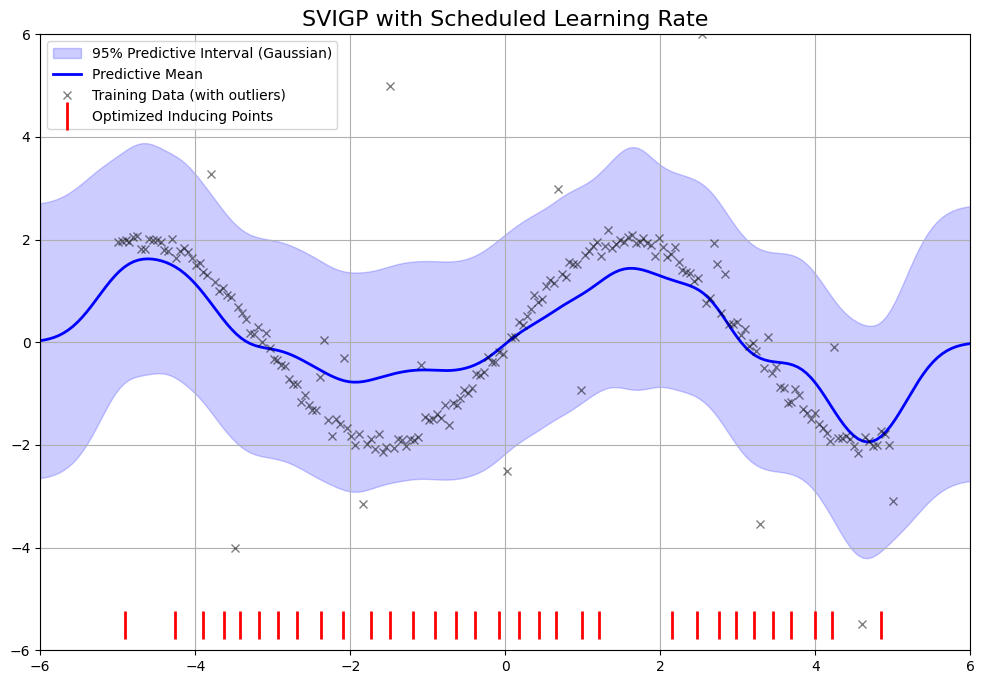

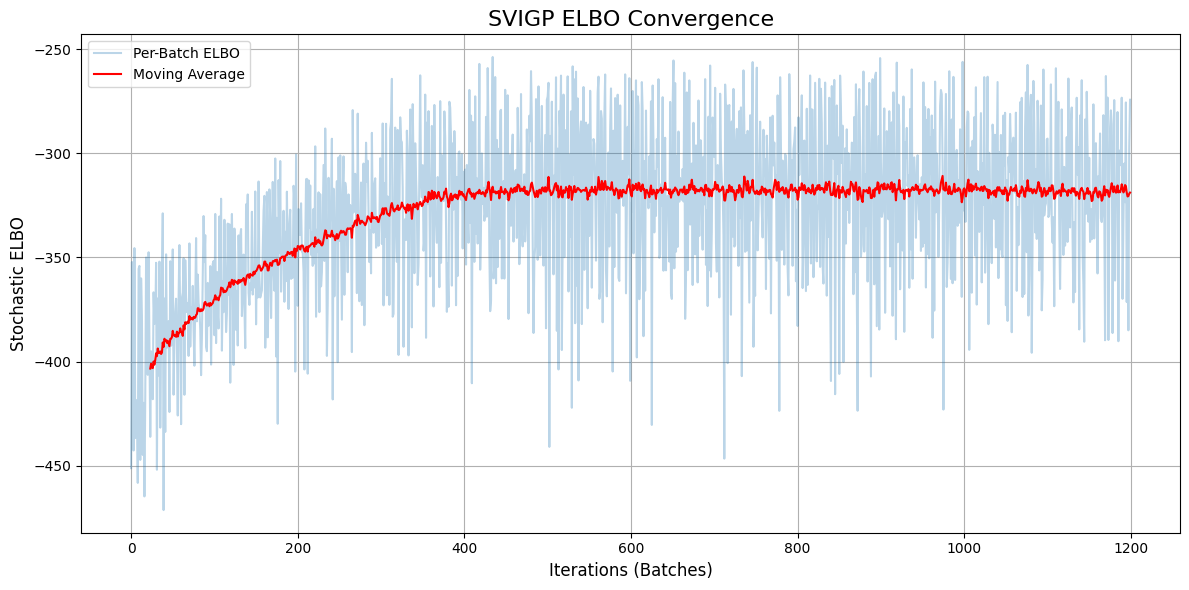

In [37]:

if __name__ == '__main__':
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 32
    model = SVIGP(
        X=X_train,
        y=y_train,
        M=M,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_noise=1.0
    )

    # --- 3. モデルの学習 (with scheduled learning rate) ---
    elbo_history = model.fit(
        epochs=300,
        batch_size=50,
        lr=0.01,
        base_lr=1.0,      # Overall scale
        kappa_e=0.9,      # Inter-epoch decay rate (0.5 < kappa_e <= 1.0)
        tau_e=1.0,        # Inter-epoch stabilization
        tau_b=1.0         # Intra-epoch stabilization
    )

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var.clamp(min=1e-9))
    pred_mean_1d = pred_mean.squeeze()
    lower = pred_mean_1d - 1.96 * pred_std
    upper = pred_mean_1d + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower, upper, color='blue', alpha=0.2, label='95% Predictive Interval (Gaussian)')
    plt.plot(X_test, pred_mean, 'b-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach().cpu(), torch.full_like(model.Z.detach().cpu(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('SVIGP with Scheduled Learning Rate', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean()
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('SVIGP ELBO Convergence', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [24]:

if __name__ == '__main__':
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.2
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    # outlier_indices = torch.randperm(N)[:20]
    # y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    # y_train[30] = -4.0
    # y_train[70] = 5.0
    # y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 50
    model = SVIGP(
        X=X_train,
        y=y_train,
        M=M,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_noise=0.5
    )

    # --- 3. モデルの学習 (with scheduled learning rate) ---
    elbo_history = model.fit(
        epochs=1000,
        batch_size=100,
        lr=0.01,
        base_lr=1.0,      # Overall scale
        kappa_e=0.7,      # Inter-epoch decay rate (0.5 < kappa_e <= 1.0)
        tau_e=1.0,        # Inter-epoch stabilization
        tau_b=1.0         # Intra-epoch stabilization
    )

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var.clamp(min=1e-9))
    pred_mean_1d = pred_mean.squeeze()
    lower = pred_mean_1d - 1.96 * pred_std
    upper = pred_mean_1d + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower, upper, color='blue', alpha=0.2, label='95% Predictive Interval (Gaussian)')
    plt.plot(X_test, pred_mean, 'b-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach().cpu(), torch.full_like(model.Z.detach().cpu(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('SVIGP with Scheduled Learning Rate', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean()
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('SVIGP ELBO Convergence', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Starting SVIGP optimization for 1000 epochs with scheduled learning rate...


Epoch 10/1000, Final Batch ELBO: -644.6501, Rho: 0.062216
Epoch 20/1000, Final Batch ELBO: -526.0827, Rho: 0.039566
Epoch 30/1000, Final Batch ELBO: -520.8400, Rho: 0.030125
Epoch 40/1000, Final Batch ELBO: -459.4471, Rho: 0.024770
Epoch 50/1000, Final Batch ELBO: -407.1868, Rho: 0.021261
Epoch 60/1000, Final Batch ELBO: -394.5816, Rho: 0.018756
Epoch 70/1000, Final Batch ELBO: -376.1619, Rho: 0.016865
Epoch 80/1000, Final Batch ELBO: -345.1974, Rho: 0.015379
Epoch 90/1000, Final Batch ELBO: -324.9914, Rho: 0.014176


KeyboardInterrupt: 

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/4 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/4 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/4 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/4 [00:00<?, ?it/s]

...

Minibatch:   0%|          | 0/4 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/4 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/4 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/4 [00:00<?, ?it/s]


Training finished.


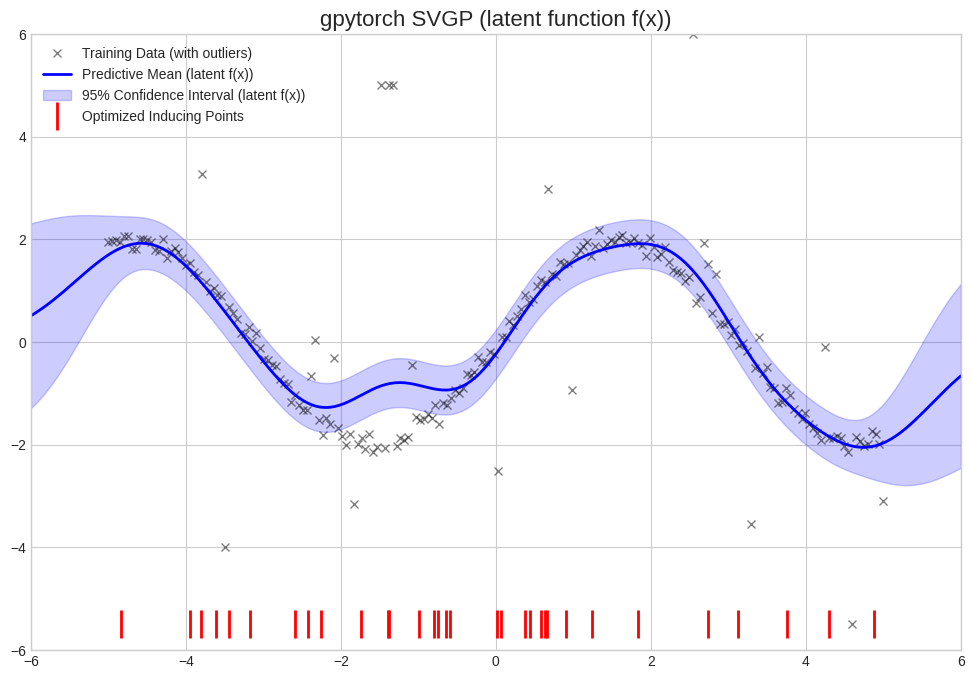

In [58]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
import tqdm

def plot_results(model, likelihood, X_train, y_train, X_test):
    model.eval()
    likelihood.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # 潜在関数 f(x) の分布
        latent_pred = model(X_test)
        pred_mean = latent_pred.mean.cpu()
        pred_std = latent_pred.stddev.cpu()
        lower = pred_mean - 1.96 * pred_std
        upper = pred_mean + 1.96 * pred_std

    plt.figure(figsize=(12, 8))
    plt.plot(X_train.cpu().numpy(), y_train.cpu().numpy(), 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(X_test.cpu().numpy(), pred_mean.numpy(), 'b-', lw=2, label='Predictive Mean (latent f(x))')
    plt.fill_between(X_test.squeeze().cpu().numpy(), lower.numpy(), upper.numpy(), 
                     color='blue', alpha=0.2, label='95% Confidence Interval (latent f(x))')

    # 誘導点をプロット
    inducing_points = model.variational_strategy.inducing_points.detach().cpu().numpy()
    plt.plot(inducing_points, torch.full_like(torch.from_numpy(inducing_points), -5.5), 
             'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('gpytorch SVGP (latent function f(x))', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()


# --- 1. データセットの準備 ---
torch.set_default_dtype(torch.float64)
torch.manual_seed(42)

N = 200
X_train = torch.linspace(-5, 5, N).unsqueeze(1)
y_true = torch.sin(X_train) * 2

noise = torch.randn(N, 1) * 0.1
t_dist_sample = torch.distributions.StudentT(df=2)
outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
y_train = y_true + noise
outlier_indices = torch.randperm(N)[:20]
y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
y_train[30] = -4.0
y_train[70] = 5.0
y_train[72] = 5.0
y_train[73] = 5.0
y_train[150] = 6.0

# ターゲット変数を1次元にする (gpytorchの仕様)
y_train = y_train.squeeze(-1)

# CUDAが利用可能ならGPUを使用
if torch.cuda.is_available():
    X_train, y_train = X_train.cuda(), y_train.cuda()

# データローダーの作成
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)

# --- 2. モデルの定義 ---
# NGDを使用するためのSVGPモデル
class GPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        # NGDを使用するには NaturalVariationalDistribution を使う
        variational_distribution = gpytorch.variational.NaturalVariationalDistribution(inducing_points.size(0))
        
        # VariationalStrategyの設定
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super(GPModel, self).__init__(variational_strategy)
        
        # 平均関数とカーネル関数
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# --- 3. モデルと尤度の初期化 ---
M = 32  # 誘導点の数
initial_inducing_points = X_train[torch.randperm(N)[:M]]

model = GPModel(inducing_points=initial_inducing_points)
likelihood = gpytorch.likelihoods.GaussianLikelihood()

if torch.cuda.is_available():
    model = model.cuda()
    likelihood = likelihood.cuda()

# --- 4. オプティマイザの定義 ---
# NGDは変分パラメータのみを更新する
variational_ngd_optimizer = gpytorch.optim.NGD(model.variational_parameters(), num_data=y_train.size(0), lr=0.1)

# Adamはハイパーパラメータ（カーネルパラメータなど）を更新する
hyperparameter_optimizer = torch.optim.Adam([
    {'params': model.hyperparameters()},
    {'params': likelihood.parameters()},
], lr=0.01)

# --- 5. 訓練ループ ---
model.train()
likelihood.train()

# 目的関数 (ELBO)
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y_train.size(0))

num_epochs = 100
epochs_iter = tqdm.notebook.tqdm(range(num_epochs), desc="Epoch")

for i in epochs_iter:
    minibatch_iter = tqdm.notebook.tqdm(train_loader, desc="Minibatch", leave=False)

    for x_batch, y_batch in minibatch_iter:
        # 勾配をゼロに初期化
        variational_ngd_optimizer.zero_grad()
        hyperparameter_optimizer.zero_grad()

        # 順伝播
        output = model(x_batch)
        
        # 損失（負のELBO）を計算
        loss = -mll(output, y_batch)
        
        minibatch_iter.set_postfix(loss=loss.item())
        
        # 逆伝播
        loss.backward()
        
        # オプティマイザのステップ
        variational_ngd_optimizer.step()
        hyperparameter_optimizer.step()

print("\nTraining finished.")

# --- 6. 結果の可視化 ---
X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
if torch.cuda.is_available():
    X_test = X_test.cuda()
    
plot_results(model, likelihood, X_train, y_train, X_test)

In [57]:
latent_pred = model(X_test)
latent_pred.stddev

tensor([0.9185, 0.9019, 0.8827, 0.8609, 0.8364, 0.8092, 0.7793, 0.7470, 0.7125,
        0.6760, 0.6379, 0.5988, 0.5592, 0.5197, 0.4810, 0.4437, 0.4085, 0.3762,
        0.3472, 0.3222, 0.3013, 0.2846, 0.2719, 0.2628, 0.2566, 0.2526, 0.2502,
        0.2488, 0.2480, 0.2474, 0.2469, 0.2463, 0.2458, 0.2452, 0.2446, 0.2440,
        0.2436, 0.2433, 0.2431, 0.2430, 0.2430, 0.2430, 0.2431, 0.2432, 0.2434,
        0.2435, 0.2436, 0.2436, 0.2437, 0.2437, 0.2437, 0.2437, 0.2438, 0.2438,
        0.2438, 0.2438, 0.2438, 0.2438, 0.2437, 0.2437, 0.2436, 0.2435, 0.2434,
        0.2432, 0.2431, 0.2430, 0.2428, 0.2427, 0.2425, 0.2424, 0.2423, 0.2422,
        0.2422, 0.2423, 0.2423, 0.2425, 0.2427, 0.2429, 0.2431, 0.2433, 0.2436,
        0.2438, 0.2440, 0.2441, 0.2441, 0.2441, 0.2441, 0.2439, 0.2438, 0.2436,
        0.2433, 0.2431, 0.2429, 0.2428, 0.2427, 0.2426, 0.2426, 0.2426, 0.2427,
        0.2428, 0.2429, 0.2430, 0.2431, 0.2432, 0.2433, 0.2434, 0.2434, 0.2433,
        0.2433, 0.2432, 0.2431, 0.2430, 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Keep the provided kernel function
def rbf_kernel(X1, X2, lengthscale, variance):
    """
    Computes the RBF kernel matrix.
    """
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)


class SVIGP(nn.Module):
    """
    Implementation of the Stochastic Variational Inference Gaussian Process (SVIGP)
    with the CORRECT update rule for variational parameters performed in the
    natural parameter space.
    """
    def __init__(self, X, y, M, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_noise=0.1, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        self.Z = nn.Parameter(self._initialize_inducing_points())
        if not hasattr(kernel_lengthscale, "__len__"):
            kernel_lengthscale = torch.tensor([kernel_lengthscale] * self.D, dtype=dtype)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))
        self.log_beta = nn.Parameter(torch.log(torch.tensor(1.0 / likelihood_noise**2, dtype=dtype)))

        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('L_u', torch.eye(self.M, dtype=dtype))

        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "beta": torch.exp(self.log_beta)
        }

    def _calculate_elbo(self, X_batch, y_batch):
        pass

    def fit(self, epochs=100, batch_size=128, lr=0.01, rho=0.01):
        optimizer = optim.Adam(self.parameters(), lr=lr)
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting SVIGP optimization for {epochs} epochs...")
        
        jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
        
        for epoch in range(epochs):
            for X_batch, y_batch in dataloader:
                B = X_batch.shape[0]
                params = self._get_params()
                
                with torch.no_grad():

                optimizer.zero_grad()
                elbo = self._calculate_elbo(X_batch, y_batch)
                loss = -elbo
                loss.backward()
                optimizer.step()
                elbo_history.append(elbo.item())

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo.item():.4f}")
                
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        with torch.no_grad():


Starting SVIGP optimization for 100 epochs...


Epoch 10/100, Final Batch ELBO: -893.0615
Epoch 20/100, Final Batch ELBO: -740.4171
Epoch 30/100, Final Batch ELBO: -741.3460
Epoch 40/100, Final Batch ELBO: -661.9020
Epoch 50/100, Final Batch ELBO: -605.5009
Epoch 60/100, Final Batch ELBO: -600.1046
Epoch 70/100, Final Batch ELBO: -572.5914
Epoch 80/100, Final Batch ELBO: -545.6807
Epoch 90/100, Final Batch ELBO: -517.0302
Epoch 100/100, Final Batch ELBO: -524.2739

Optimization finished.


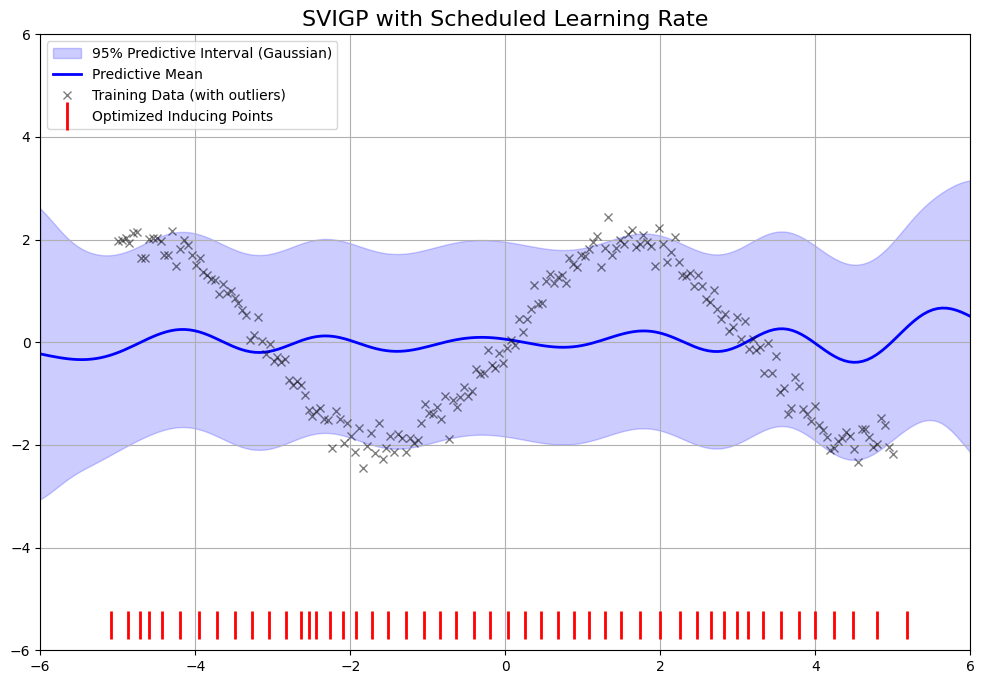

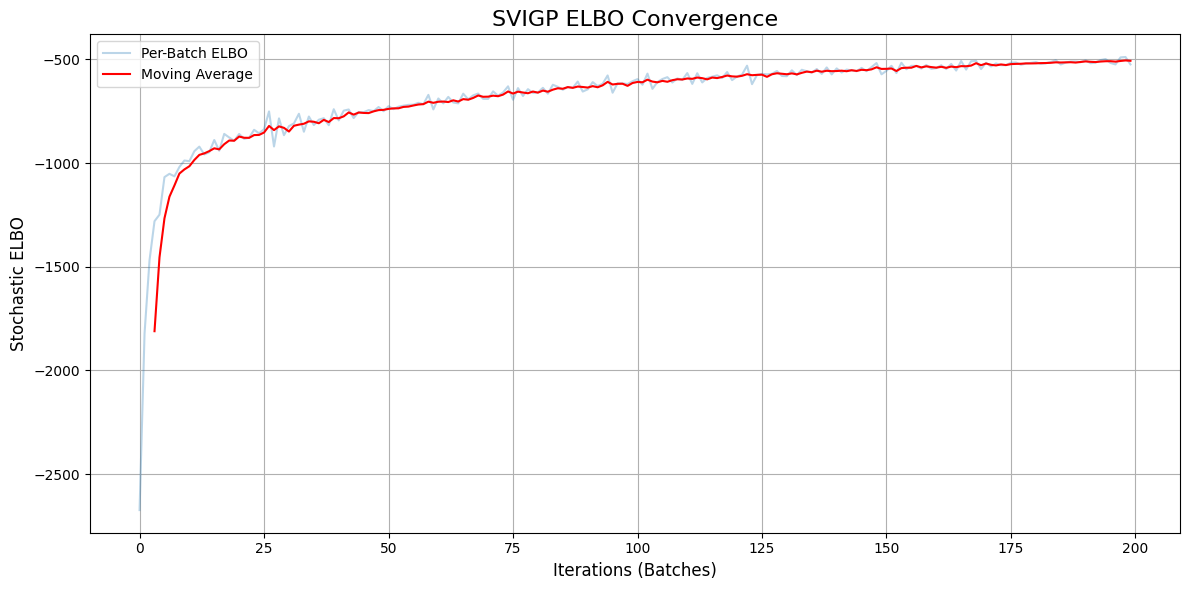

In [46]:

if __name__ == '__main__':
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.2
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    # outlier_indices = torch.randperm(N)[:20]
    # y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    # y_train[30] = -4.0
    # y_train[70] = 5.0
    # y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 50
    model = SVIGP(
        X=X_train,
        y=y_train,
        M=M,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_noise=0.5
    )

    # --- 3. モデルの学習 (with scheduled learning rate) ---
    elbo_history = model.fit(
        epochs=100,
        batch_size=100,
        lr=0.01,
    )

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var.clamp(min=1e-9))
    pred_mean_1d = pred_mean.squeeze()
    lower = pred_mean_1d - 1.96 * pred_std
    upper = pred_mean_1d + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower, upper, color='blue', alpha=0.2, label='95% Predictive Interval (Gaussian)')
    plt.plot(X_test, pred_mean, 'b-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach().cpu(), torch.full_like(model.Z.detach().cpu(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('SVIGP with Scheduled Learning Rate', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean()
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('SVIGP ELBO Convergence', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Starting SVIGP optimization for 200 epochs...


Epoch 10/200, Final Batch ELBO: 339.2626
Epoch 20/200, Final Batch ELBO: 471.9330
Epoch 30/200, Final Batch ELBO: 453.1982
Epoch 40/200, Final Batch ELBO: 445.5035
Epoch 50/200, Final Batch ELBO: 471.9886
Epoch 60/200, Final Batch ELBO: 408.3718
Epoch 70/200, Final Batch ELBO: 411.8263
Epoch 80/200, Final Batch ELBO: 356.4546
Epoch 90/200, Final Batch ELBO: 417.7107
Epoch 100/200, Final Batch ELBO: 397.6324
Epoch 110/200, Final Batch ELBO: 415.2447
Epoch 120/200, Final Batch ELBO: 471.2350
Epoch 130/200, Final Batch ELBO: 365.4008
Epoch 140/200, Final Batch ELBO: 387.7984
Epoch 150/200, Final Batch ELBO: 385.1466
Epoch 160/200, Final Batch ELBO: 389.8845
Epoch 170/200, Final Batch ELBO: 435.6370
Epoch 180/200, Final Batch ELBO: 361.7728
Epoch 190/200, Final Batch ELBO: 377.9985
Epoch 200/200, Final Batch ELBO: 398.4925

Optimization finished.


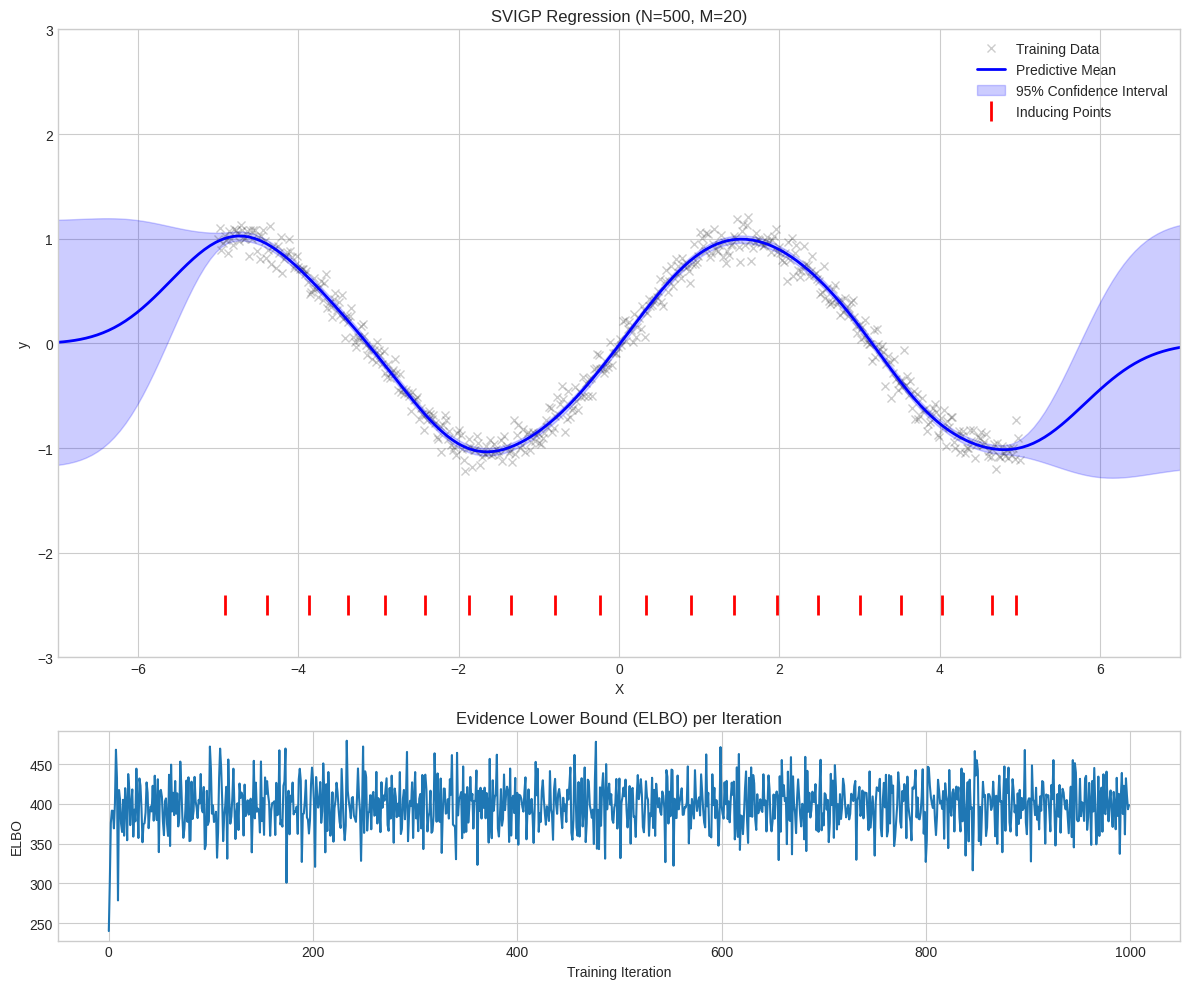

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Keep the provided kernel function
def rbf_kernel(X1, X2, lengthscale, variance):
    """
    Computes the RBF kernel matrix.
    """
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)


class SVIGP(nn.Module):
    """
    Implementation of the Stochastic Variational Inference Gaussian Process (SVIGP)
    with the CORRECT update rule for variational parameters performed in the
    natural parameter space.
    """
    def __init__(self, X, y, M, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_noise=0.1, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        self.Z = nn.Parameter(self._initialize_inducing_points())
        if not hasattr(kernel_lengthscale, "__len__"):
            kernel_lengthscale = torch.tensor([kernel_lengthscale] * self.D, dtype=dtype)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))
        self.log_beta = nn.Parameter(torch.log(torch.tensor(1.0 / likelihood_noise**2, dtype=dtype)))

        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('L_u', torch.eye(self.M, dtype=dtype))

        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "beta": torch.exp(self.log_beta)
        }

    def _calculate_elbo(self, X_batch, y_batch):
        B = X_batch.shape[0]
        params = self._get_params()
        
        jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
        
        # Kernel matrices
        K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        K_bb_diag = params['variance'] * torch.ones(B, device=self.device, dtype=self.X_full.dtype)

        L_Kmm = torch.linalg.cholesky(K_mm + jitter)
        
        # A = K_mm^{-1} @ K_mb
        A = torch.cholesky_solve(K_mb, L_Kmm)

        # Variational covariance S_u = L_u @ L_u.T
        S_u = self.L_u @ self.L_u.T

        # --- Calculate the three terms of the scaled log-likelihood ---
        
        # 1. Expected log-likelihood term
        mu_b = A.T @ self.m_u
        log_lik_term = (
            0.5 * B * torch.log(params['beta']) -
            0.5 * B * math.log(2 * math.pi) -
            0.5 * params['beta'] * ((y_batch - mu_b)**2).sum()
        )
        
        # 2. Trace term related to the prior variance
        psi_trace_term = -0.5 * params['beta'] * (K_bb_diag.sum() - (A * K_mb).sum())
        
        # 3. Trace term related to the variational covariance
        S_trace_term = -0.5 * params['beta'] * (A.T @ S_u @ A).trace()

        # Scale the likelihood-related terms
        scaled_log_lik = (log_lik_term + psi_trace_term + S_trace_term) * (self.N / B)
        
        # --- Calculate the KL divergence KL(q(u) || p(u)) ---
        K_mm_inv_S = torch.cholesky_solve(S_u, L_Kmm)
        trace_kl = K_mm_inv_S.trace()
        mahalanobis_kl = (self.m_u.T @ torch.cholesky_solve(self.m_u, L_Kmm)).squeeze()
        log_det_kl = 2 * torch.log(L_Kmm.diag()).sum() - 2 * torch.log(self.L_u.diag()).sum()
        
        kl_div = 0.5 * (trace_kl + mahalanobis_kl - self.M + log_det_kl)
        
        # Final ELBO
        elbo = scaled_log_lik - kl_div
        return elbo

    def fit(self, epochs=100, batch_size=128, lr=0.01, rho=0.01):
        optimizer = optim.Adam(self.parameters(), lr=lr)
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting SVIGP optimization for {epochs} epochs...")
        
        jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
        
        for epoch in range(epochs):
            for X_batch, y_batch in dataloader:
                B = X_batch.shape[0]
                params = self._get_params()
                
                with torch.no_grad():
                    # --- Stochastic Variational Update for m_u and L_u ---
                    # This part does not use auto-grad but updates the variational
                    # parameters directly using the natural gradient update rule.
                    
                    # Compute kernel matrices
                    K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
                    K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
                    K_mm_inv = torch.inverse(K_mm + jitter)
                    
                    # Compute intermediate matrix T = K_mm^{-1} @ K_mb
                    T = K_mm_inv @ K_mb
                    
                    # Optimal natural parameters based on the current mini-batch
                    theta2_hat = -0.5 * (K_mm_inv + params["beta"] * (self.N / B) * (T @ T.T))
                    theta1_hat = params["beta"] * (self.N / B) * (T @ y_batch)
                    
                    # Current natural parameters
                    S_u_inv = torch.inverse(self.L_u @ self.L_u.T + jitter)
                    theta2_old = -0.5 * S_u_inv
                    theta1_old = S_u_inv @ self.m_u

                    # SVI update step
                    theta2_new = (1 - rho) * theta2_old + rho * theta2_hat
                    theta1_new = (1 - rho) * theta1_old + rho * theta1_hat

                    # Convert back to standard parameters (m_u, L_u)
                    S_u_inv_new = -2 * theta2_new
                    S_u_new = torch.inverse(S_u_inv_new + jitter)
                    L_u_new = torch.linalg.cholesky(S_u_new + jitter)
                    m_u_new = S_u_new @ theta1_new

                    # Update variational parameter buffers
                    self.m_u.data.copy_(m_u_new)
                    self.L_u.data.copy_(L_u_new)
                
                # --- Adam update for hyperparameters (Z, kernel, noise) ---
                optimizer.zero_grad()
                elbo = self._calculate_elbo(X_batch, y_batch)
                loss = -elbo
                loss.backward()
                optimizer.step()
                elbo_history.append(elbo.item())

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo.item():.4f}")
                
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        if X_test_dev.ndim == 1: X_test_dev = X_test_dev.unsqueeze(1)
        
        with torch.no_grad():
            params = self._get_params()
            jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
            
            # Kernel matrices
            K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
            K_sm = self.kernel(X_test_dev, self.Z, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'] * torch.ones(X_test_dev.shape[0], device=self.device, dtype=self.X_full.dtype)

            L_Kmm = torch.linalg.cholesky(K_mm + jitter)
            
            # A = K_sm @ K_mm^{-1}
            A = K_sm @ torch.inverse(K_mm + jitter)

            # Predictive mean: E[f*] = K_{s,m} @ K_{m,m}^{-1} @ m_u
            pred_mean = A @ self.m_u
            
            # Predictive variance: Var[f*]
            S_u = self.L_u @ self.L_u.T
            
            # Term 1: diag(K_ss)
            var_term1 = K_ss_diag
            # Term 2: -diag(K_sm @ K_mm^{-1} @ K_ms)
            var_term2 = -(A * K_sm).sum(dim=1)
            # Term 3: diag(K_sm @ K_mm^{-1} @ S_u @ K_mm^{-1} @ K_ms)
            var_term3 = (A.T * (S_u @ A.T)).sum(dim=0)
            
            pred_var = var_term1 + var_term2 + var_term3
            
            return pred_mean.squeeze(), pred_var.squeeze()

# Example Usage
if __name__ == '__main__':
    # --- Generate Toy Data ---
    N_train = 500
    X_train = torch.linspace(-5, 5, N_train)
    y_train = torch.sin(X_train) + torch.randn(N_train) * 0.1
    
    # --- Initialize and Train the Model ---
    M = 20  # Number of inducing points
    model = SVIGP(X_train, y_train, M=M)
    
    # Fit the model
    # Note: SVI can be sensitive to learning rates. These are reasonable starting points.
    # rho is the learning rate for the variational parameters.
    # lr is the learning rate for the hyperparameters.
    elbo_history = model.fit(epochs=200, batch_size=100, lr=0.01, rho=0.05)

    # --- Make Predictions ---
    X_test = torch.linspace(-7, 7, 200)
    pred_mean, pred_var = model.predict(X_test)
    pred_std = torch.sqrt(pred_var)
    
    # Move results to CPU for plotting
    X_train_cpu = model.X_full.cpu()
    y_train_cpu = model.y_full.cpu()
    X_test_cpu = X_test.cpu()
    Z_cpu = model.Z.detach().cpu()
    pred_mean_cpu = pred_mean.cpu()
    pred_std_cpu = pred_std.cpu()

    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # Plot training data, predictions, and inducing points
    ax1.plot(X_train_cpu, y_train_cpu, 'kx', alpha=0.2, label='Training Data')
    ax1.plot(X_test_cpu, pred_mean_cpu, color='blue', lw=2, label='Predictive Mean')
    ax1.fill_between(
        X_test_cpu,
        pred_mean_cpu - 2 * pred_std_cpu,
        pred_mean_cpu + 2 * pred_std_cpu,
        color='blue',
        alpha=0.2,
        label='95% Confidence Interval'
    )
    ax1.plot(Z_cpu, torch.zeros_like(Z_cpu)-2.5, 'r|', markersize=15, markeredgewidth=2, label='Inducing Points')
    ax1.set_title(f'SVIGP Regression (N={N_train}, M={M})')
    ax1.set_xlabel('X')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.set_ylim(-3, 3)
    ax1.set_xlim(-7, 7)

    # Plot ELBO history
    ax2.plot(elbo_history)
    ax2.set_title('Evidence Lower Bound (ELBO) per Iteration')
    ax2.set_xlabel('Training Iteration')
    ax2.set_ylabel('ELBO')

    plt.tight_layout()
    plt.show()

Starting SVIGP optimization for 100 epochs...


Epoch 10/100, Final Batch ELBO: -781.1073
Epoch 20/100, Final Batch ELBO: -616.1104
Epoch 30/100, Final Batch ELBO: -601.1983
Epoch 40/100, Final Batch ELBO: -486.8644
Epoch 50/100, Final Batch ELBO: -389.8827
Epoch 60/100, Final Batch ELBO: -423.6262
Epoch 70/100, Final Batch ELBO: -380.9071
Epoch 80/100, Final Batch ELBO: -501.0657
Epoch 90/100, Final Batch ELBO: -519.3440
Epoch 100/100, Final Batch ELBO: -451.4329

Optimization finished.


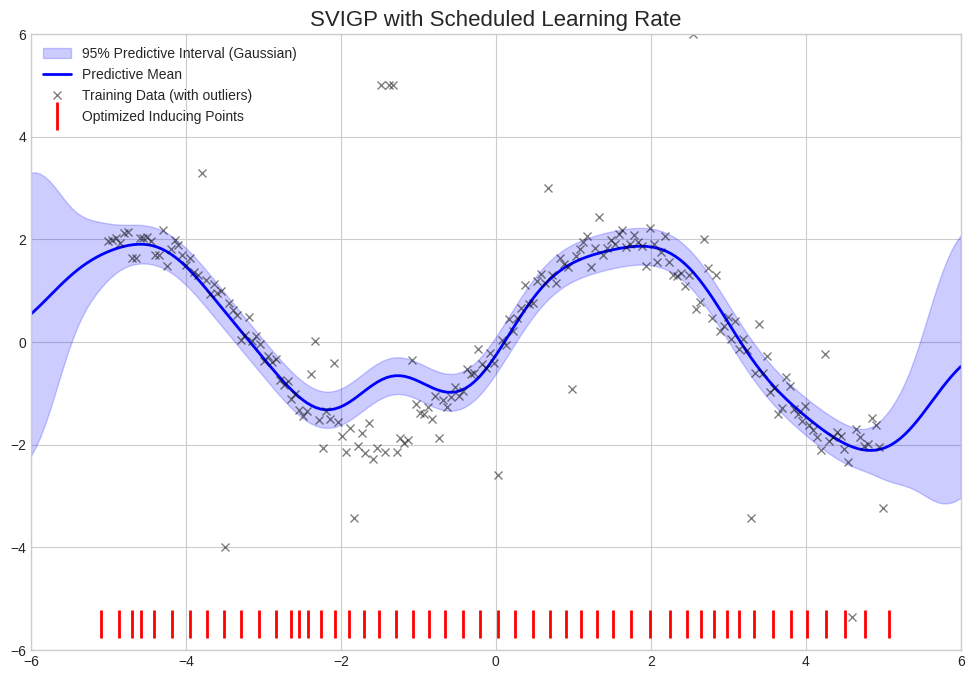

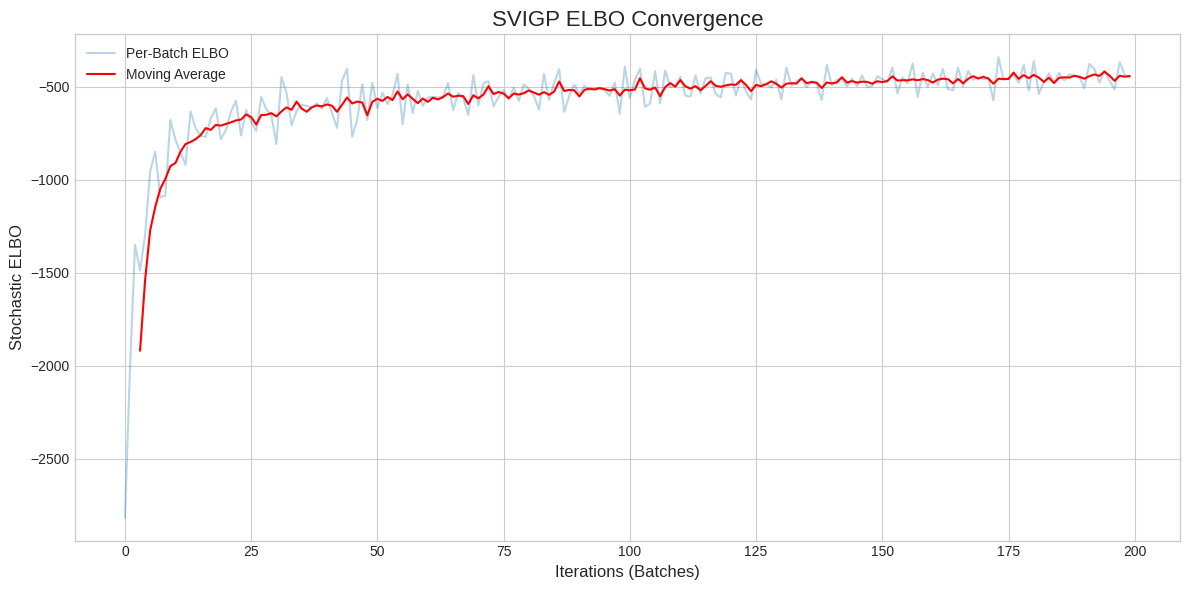

In [51]:

if __name__ == '__main__':
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.2
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[72] = 5.0
    y_train[73] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 50
    model = SVIGP(
        X=X_train,
        y=y_train,
        M=M,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_noise=0.5
    )

    # --- 3. モデルの学習 (with scheduled learning rate) ---
    elbo_history = model.fit(
        epochs=100,
        batch_size=100,
        lr=0.01,
    )

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var.clamp(min=1e-9))
    pred_mean_1d = pred_mean.squeeze()
    lower = pred_mean_1d - 1.96 * pred_std
    upper = pred_mean_1d + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower, upper, color='blue', alpha=0.2, label='95% Predictive Interval (Gaussian)')
    plt.plot(X_test, pred_mean, 'b-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach().cpu(), torch.full_like(model.Z.detach().cpu(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('SVIGP with Scheduled Learning Rate', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean()
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('SVIGP ELBO Convergence', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()